In [ ]:
import sys
from pathlib import Path



# Find project root (folder containing pyproject.toml), then add src/
project_root = None
p = Path.cwd().resolve()
for d in [p, *p.parents]:
    if (d / "pyproject.toml").exists():
        project_root = d
        sys.path.insert(0, str(d / "src"))
        break
if project_root is None:
    raise RuntimeError("Could not find project root (pyproject.toml)")

import matplotlib.pyplot as plt
import numpy as np
from smatrix import sw_propagator
from model import self_energy
from eigenstate_solving.eigen_eq_integrand import BZ_proj
from smatrix import (
    create_self_energy_interpolator_numba,
    square_lattice,
    t,
    t_reg,
    legs,
    sw_propagator
)

sigma_path = project_root / "data" / "sigma_grid0f1a.npz"
if not sigma_path.exists():
    raise FileNotFoundError(f"Missing data file: {sigma_path}")

sigma_data = np.load(sigma_path)
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)


E =  2*square_lattice.omega_e
E1 = square_lattice.omega_e
#evaluated_q = np.array([600, np.sqrt(E**2 - 600**2) - 1])
evaluated_q = np.array([0,10])
Q = np.array([0,0])







(-10.363903633709981-12.051166804197807j)
(-12.94550145978235-17.317240227536363j)


In [8]:
from joblib import Parallel, delayed

k_grid = np.linspace(-E, E, 100)
kx, ky = np.meshgrid(k_grid, k_grid, indexing="ij")
k_para_list = np.column_stack((kx.ravel(), ky.ravel()))


def _compute_t_chunk(k_chunk):
    trans_amp = t(k_chunk, E, square_lattice, sigma_func_period=None)
    trans_amp_bm = t(
        k_chunk, E, square_lattice, sigma_func_period=sigma_func_period_numba
    )
    return np.atleast_1d(trans_amp), np.atleast_1d(trans_amp_bm)

"""
n_chunks = min(6, len(k_para_list))
k_chunks = [chunk for chunk in np.array_split(k_para_list, n_chunks) if len(chunk) > 0]
chunk_results = Parallel(n_jobs=6, backend="loky")(
    delayed(_compute_t_chunk)(k_chunk) for k_chunk in k_chunks
)

trans_amp_list = np.concatenate([res[0] for res in chunk_results])
trans_amp_list_BM = np.concatenate([res[1] for res in chunk_results])
plots_list = np.abs(trans_amp_list - trans_amp_list_BM) / np.abs(trans_amp_list)

# Build a colormap on the (kx, ky) coordinates from k_para_list
x = k_para_list[:, 0]
y = k_para_list[:, 1]

plt.figure(figsize=(6, 5))
col = plt.tricontourf(x, y, plots_list, levels=30, cmap="viridis")
plt.scatter(x, y, c=plots_list, s=10, cmap="viridis", edgecolors="none")
plt.colorbar(col, label=r"$|t - t_{\Sigma}|/|t|$")
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title("Transmission amplitude difference on k-grid")
plt.tight_layout()
plt.show()
"""


<>:33: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:33: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
/var/folders/0p/5ny7ry_s19l1lw9vdr0rl8_r0000gp/T/ipykernel_51849/4200830714.py:33: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  plt.colorbar(col, label=r"$|t - t_{\Sigma}|/|t|$")


'\nn_chunks = min(6, len(k_para_list))\nk_chunks = [chunk for chunk in np.array_split(k_para_list, n_chunks) if len(chunk) > 0]\nchunk_results = Parallel(n_jobs=6, backend="loky")(\n    delayed(_compute_t_chunk)(k_chunk) for k_chunk in k_chunks\n)\n\ntrans_amp_list = np.concatenate([res[0] for res in chunk_results])\ntrans_amp_list_BM = np.concatenate([res[1] for res in chunk_results])\nplots_list = np.abs(trans_amp_list - trans_amp_list_BM) / np.abs(trans_amp_list)\n\n# Build a colormap on the (kx, ky) coordinates from k_para_list\nx = k_para_list[:, 0]\ny = k_para_list[:, 1]\n\nplt.figure(figsize=(6, 5))\ncol = plt.tricontourf(x, y, plots_list, levels=30, cmap="viridis")\nplt.scatter(x, y, c=plots_list, s=10, cmap="viridis", edgecolors="none")\nplt.colorbar(col, label=r"$|t - t_{\\Sigma}|/|t|$")\nplt.xlabel(r"$k_x$")\nplt.ylabel(r"$k_y$")\nplt.title("Transmission amplitude difference on k-grid")\nplt.tight_layout()\nplt.show()\n'

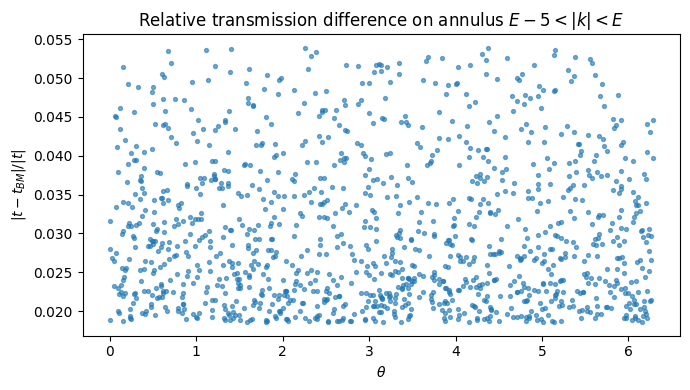

In [12]:
# Additional sampling on annulus E-10 < |k| < E
n_ring_samples = 1200
theta_ring = np.random.uniform(0.0, 2*np.pi, n_ring_samples)
radius_ring = np.random.uniform(E-15.0, E-5, n_ring_samples)
k_ring = np.column_stack(
    (radius_ring * np.cos(theta_ring), radius_ring * np.sin(theta_ring))
)

n_ring_chunks = min(6, len(k_ring))
k_ring_chunks = [chunk for chunk in np.array_split(k_ring, n_ring_chunks) if len(chunk) > 0]
ring_chunk_results = Parallel(n_jobs=6, backend="loky")(
    delayed(_compute_t_chunk)(k_chunk) for k_chunk in k_ring_chunks
)

trans_amp_ring = np.concatenate([res[0] for res in ring_chunk_results])
trans_amp_ring_BM = np.concatenate([res[1] for res in ring_chunk_results])
ring_diff = np.abs(trans_amp_ring - trans_amp_ring_BM) / np.abs(trans_amp_ring)

theta_sorted_idx = np.argsort(theta_ring)
plt.figure(figsize=(7, 4))
plt.scatter(theta_ring[theta_sorted_idx], ring_diff[theta_sorted_idx], s=8, alpha=0.6)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$|t - t_{BM}|/|t|$")
plt.title(r"Relative transmission difference on annulus $E-5 < |k| < E$")
plt.tight_layout()
plt.show()

In [4]:
n_samples = 6**3
k_para_list = []
for i in range(0, n_samples):
    U = np.random.uniform(0, 1.0)
    theta = np.random.uniform(0, 2 * np.pi)

    kx = E * np.sqrt(U) * np.cos(theta)
    ky = E * np.sqrt(U) * np.sin(theta)
    k_para_list.append(np.array([kx, ky]))
k_para_list = np.array(k_para_list)
# print(np.shape(k_para_list))


In [ ]:
from joblib import Parallel, delayed

Q_para = np.array([0.0, 0.0])
eps = 1e-3  # avoid zero-division at integration boundaries
n_energy_points = 30


def _sample_for_k(
    k_para: np.ndarray,
    Q_para: np.ndarray,
    E: float,
    eps: float,
    n_energy_points: int,
):
    l_para = BZ_proj(Q_para - k_para, square_lattice)
    width = E - np.linalg.norm(k_para) - np.linalg.norm(l_para)
    if width <= 0:
        return []

    E1_grid = np.linspace(
        np.linalg.norm(k_para) + eps,
        E - np.linalg.norm(l_para) - eps,
        n_energy_points,
    )
    return [
        S_disconnected(k_para, E1, l_para, E - E1, square_lattice, None)
        for E1 in E1_grid
    ]


samples_nested = Parallel(n_jobs=6, backend="loky", verbose=3)(
    delayed(_sample_for_k)(k_para, Q_para, E, eps, n_energy_points)
    for k_para in k_para_list
)
samples = np.array(
    [value for chunk in samples_nested for value in chunk], dtype=complex
)

# print(samples)
plt.scatter(samples.real, samples.imag)
